In [1]:
# Import Libraries
import math
import random
import numpy as np 
import pandas as pd 
import statistics as stat
import matplotlib.pyplot as plt
import itertools as iter 
from scipy.stats import norm

## Functions:

In [ ]:
# Create a random deck of cards
def card_deck(deck_size:int) -> list:
    deck = [x for x in range(1,deck_size+1)]
    a_deck = deck[:]
    random.shuffle(a_deck)
    return a_deck

# Perform a riffle shuffle on deck
def riffle_shuffle(current_deck:list) -> list:

    # Split the deck in two
    swing = random.randint(-5,5)
    part_a = current_deck[:int(len(current_deck)/2)+swing] 
    part_b = current_deck[int(len(current_deck)/2)+swing:]

    # Build new deck with alternating parts of old deck
    new_deck = []
    while len(part_a) > 0 and len(part_b) > 0:
        rand_a = random.randint(1,3)
        rand_b = random.randint(1,3)
        card_pop_a = min(rand_a, len(part_a))
        card_pop_b = min(rand_b, len(part_b)) 
        new_deck.insert(0, part_a[-card_pop_a:])
        new_deck.insert(0, part_b[-card_pop_b:])
        part_a = part_a[0:-card_pop_a]
        part_b = part_b[0:-card_pop_b]
    if len(part_a) == 0:
        new_deck.insert(0, part_b)
    else:
        new_deck.insert(0, part_a)
    new_deck = [x for sublist in new_deck for x in sublist]

    return new_deck

# Perform an overhand shuffle
def over_shuffle(current_deck:list) -> list:

    # Take chunk of cards from the bottom
    spl = random.randint(6,18) #assume cards left on bottom
    over_cards = current_deck[spl:]

    # New deck being created
    new_deck = current_deck[:spl]

    while len(over_cards)>7:
        cut = random.randint(1,7)
        new_deck = over_cards[:cut] + new_deck
        over_cards = over_cards[cut:]
    if len(over_cards)<=7:
        new_deck = over_cards + new_deck
    
    return new_deck

# Perform a restack of the deck
def restrack_deck(current_deck:list) -> list:

    l_pointer = int(round(52/3 + random.randint(-5,5)))
    r_pointer = l_pointer + round((52-l_pointer)/2 + random.randint(-3,3))    
    restack = [current_deck[:l_pointer], current_deck[l_pointer:r_pointer], current_deck[r_pointer:]]

    part_order = [0, 1, 2]
    while part_order == [0, 1, 2]:
        random.shuffle(part_order)
    new_deck = restack[part_order[0]] + restack[part_order[1]] + restack[part_order[2]]

    return new_deck

# Check if selected card set is found in isolated deck cards
def is_subset(card_set: list, deck_set: list) -> bool:
    return set(card_set).issubset(set(deck_set)) 

#Create library of 2,3,4-card set combinations
def create_set_library() -> list:

    # Create library of four of a kind
    set_4 = []
    for i in range(1,14):
        set_4.append([i, i+13*1, i+13*2, i+13*3])

    # Create library of three of a kind
    set_3 = []
    for i in range(len(set_4)):
        subset4 = set_4[i]
        combs = list(iter.combinations(subset4,3))
        for c in combs:
            set_3.append(list(c))

    # Create library of two of a kind
    set_2 = []
    for i in range(len(set_4)):
        subset4 = set_4[i]
        combs = list(iter.combinations(subset4,2))
        for c in combs:
            set_2.append(list(c))

    # Combine into main set
    card_sets = set_4 + set_3 + set_2 

    return card_sets, set_4, set_3, set_2

# Create library of 2,3,4-card run combinations
def create_run_library() -> list:

    # Create library of 4-card runs
    run_4 = []
    for j in range(0,4):
        for i in range(1,14-3):
            run_4.append([(j*13)+i, (j*13)+i+1, (j*13)+i+2, (j*13)+i+3])
            if i == 10:
                run_4.append([(j*13)+i+1, (j*13)+i+2, (j*13)+i+3,(j*13)+i+4-13])
    #print(run_4)

    # Create library of 3-card runs
    run_3 = []
    for j in range(0,4):
        for i in range(1,14-2):
            run_3.append([(j*13)+i, (j*13)+i+1, (j*13)+i+2])
            if i == 11:
                run_3.append([(j*13)+i+1, (j*13)+i+2, (j*13)+i+3-13])
    #print(run_3)

    # Create library of two card runs
    run_2 = []
    for j in range(0,4):
        for i in range(1,14-1):
            run_2.append([(j*13)+i, (j*13)+i+1])
            if i == 12:
                run_2.append([(j*13)+i+1, (j*13)+i+2-13])
    #print(run_2)

    #Combine runs into main set
    card_runs = run_4 + run_3 + run_2

    return card_runs, run_4, run_3, run_2

# Calculate deck's point score
def find_deck_score(deck_size:int, hand_size:int, card_sets:list, card_runs: list, test_deck:list) -> int:

    # Initialise deck score
    deck_score = 0

    #Analyse deck for rummie hands & score
    for i in range(0,deck_size-hand_size):
        hand_window = test_deck[i:i+hand_size]
        #print(hand_window, len(hand_window))

        score = 0
        for s in card_sets:
            found = is_subset(s, hand_window)
            score += found*(len(s)-1)

        for s in card_runs:
            found = is_subset(s, hand_window)
            score += found*(len(s)-1)

        deck_score += score

    return deck_score

# Remove cards from available deck once assigned to a hand
def remove_dealt_cards(c_cards: list, c_sets: list, c_runs: list):

    c_sets = [sublist for sublist in c_sets if not any(num in c_cards for num in sublist)]    
    c_runs = [sublist for sublist in c_runs if not any(num in c_cards for num in sublist)] 

    return c_sets, c_runs

# Create a post game deck from rummy
def create_game_deck(no_players: int, card_sets:list, card_runs:list) -> list:
    
    # Determine the spread of hand types
    player_hand_types = []
    for i in range(0,no_players):
        if i == 0:
            run_length = random.randint(3,4)
            if run_length == 4:
                set_length = 3
            else: 
                set_length = 4
        else:
            run_length = random.randint(1,4)
            if run_length == 4:
                set_length = random.randint(1,2)
            else: 
                set_length = random.randint(1,3)
        player_hand_types.append([set_length, run_length])

    # Create a copy of the known run and set identifiers
    c_runs = card_runs.copy()
    c_sets = card_sets.copy()

    # Add single cards to these lists and randomise their order
    a_deck = [x for x in range(1,52+1)]
    random.shuffle(a_deck)
    for x in a_deck:
        c_runs.append([x])
        c_sets.append([x]) 

    # Build the player hands
    player_hands = [[] for x in range(0, no_players)]
    for j in range(0,len(player_hand_types)):

        # Isolate the player's set and run count
        s, r = player_hand_types[j]

        # Add set count
        if s > 1:
            temp_sets = [sublist for sublist in c_sets if len(sublist)==s]
            idx = random.randint(0, len(temp_sets)-1) 
            player_hands[j].append(temp_sets[idx])
            c_sets, c_runs = remove_dealt_cards(temp_sets[idx], c_sets, c_runs)

        # Add run count
        if r > 1:
            temp_runs = [sublist for sublist in c_runs if len(sublist)==r]
            idx = random.randint(0,len(temp_runs)-1)
            player_hands[j].append(temp_runs[idx]) 
            c_sets, c_runs = remove_dealt_cards(temp_runs[idx], c_sets, c_runs)

    for j in range(0,len(player_hand_types)):

        # Isolate the player's set and run count
        s, r = player_hand_types[j]

        # Ignore single contribution count
        if s == 1:
            s = 0
        if r == 1:
            r = 0

        # Add singles
        if s+r < 7:
            no_singles = 7 - (r + s)
            temp_singles = [sublist for sublist in c_sets if len(sublist)==1]
            singles = list(iter.chain.from_iterable(temp_singles[0:(no_singles)]))
            player_hands[j].append(singles)
            c_sets, c_runs = remove_dealt_cards(singles, c_sets, c_runs)

    # Compile remaining deck cards
    remaining_deck = [sublist for sublist in c_sets if len(sublist)==1]

    # Combine into post-game deck (assume player cards put between random split remaining deck)
    used_cards = list(iter.chain.from_iterable(player_hands))
    used_cards = list(iter.chain.from_iterable(used_cards))
    remaining_deck = list(iter.chain.from_iterable(remaining_deck))
    split = random.randint(0, len(remaining_deck)-1) 
    post_deck = remaining_deck[:split] + used_cards + remaining_deck[split:]

    return post_deck

## Basic Input Parameters and Recognised Card Sets/Runs

In [3]:
# Define deck parameters & create deck
hand_size = 7
deck_size = 52

#Create libraries
card_sets, set_4, set_3, set_2 = create_set_library()
card_runs, run_4, run_3, run_2 = create_run_library()

## Analyse the typical score of random generated decks

In [4]:
# Run the first analysis
run_analysis_1 = 1
if run_analysis_1 == 1:

    # Analyse the convergence of the average score
    rand_deck_scores = []
    it = 1000
    for i in range(0,it):

        #Create test deck
        test_deck = card_deck(deck_size)

        #Calcualate deck's score
        deck_score = find_deck_score(deck_size, hand_size, card_sets, card_runs, test_deck)

        rand_deck_scores.append(deck_score)

    print("done")

done


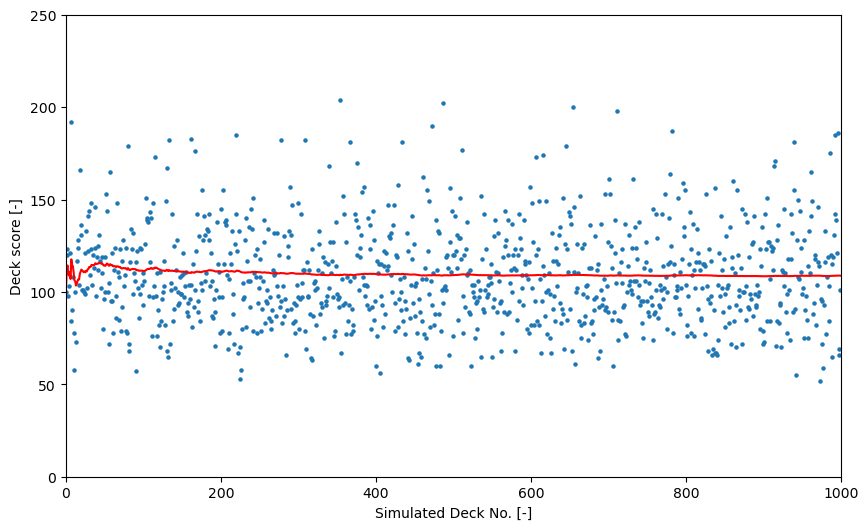

In [5]:
# Plot results
if run_analysis_1 == 1:
    X_1 = [x for x in range(0,it)]
    Y_1 = rand_deck_scores
    Y_1_avg = np.cumsum(np.array(Y_1)) / np.arange(1, len(Y_1) + 1)
    fig = plt.figure(figsize=(10,6))
    plt.scatter(X_1,Y_1, s=5)
    plt.plot(X_1,Y_1_avg,'r-')
    plt.xlim(0,it) 
    plt.ylim(0,250) 
    plt.xlabel('Simulated Deck No. [-]')
    plt.ylabel('Deck score [-]')
    plt.savefig("plots/Random Deck Scores plus Moving Average.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

Mean (mu) = 108.81
StDev (sigma) = 26.00


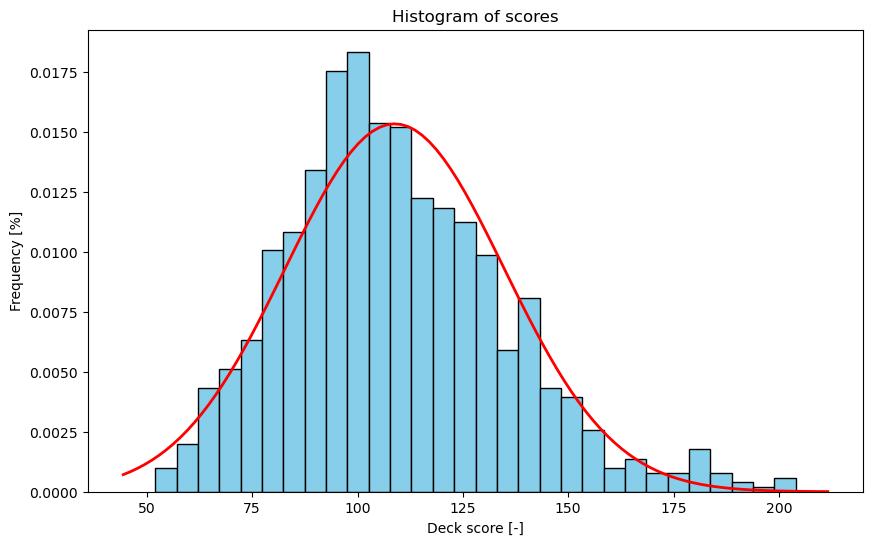

In [6]:
# Evaluate the statistic of the observed distribution
if run_analysis_1 == 1:
    # Check distribution shape
    fig = plt.figure(figsize=(10,6))
    plt.hist(Y_1, bins=30, color="skyblue", edgecolor="black", density=True)

    # Calculate statistics
    mu_1, std_1 = norm.fit(Y_1)
    print("Mean (mu) = {:.2f}\nStDev (sigma) = {:.2f}".format(mu_1, std_1))

    # Create x-value range for norm curve
    xmin, xmax = plt.xlim()
    x_1 = np.linspace(xmin, xmax, 100)
    p_1 = norm.pdf(x_1, mu_1, std_1)
    plt.plot(x_1, p_1, 'r', linewidth=2)

    #Show plot
    plt.title("Histogram of scores")
    plt.xlabel("Deck score [-]")
    plt.ylabel("Frequency [%]")
    plt.savefig("plots/Distribution of Random Deck Scores.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

In [7]:
# Save the Y data to database
if run_analysis_1 == 1:   
    df = pd.DataFrame(Y_1, columns=["Random Deck Scores"])
    df.to_csv("Study_Data.csv", index=False)    

## Construct and analyse the typical score of post-game decks

In [8]:
# Run second analysis
run_analysis_2 = 1

if run_analysis_2 == 1:

    # Decide number of players
    no_players = 4

    # Simulate 
    game_deck_scores = []
    it = 1000
    for i in range(0,it):

        #Create test deck
        test_deck = create_game_deck(no_players, card_sets, card_runs)

        #Calcualate deck's score
        deck_score = find_deck_score(deck_size, hand_size, card_sets, card_runs, test_deck)

        game_deck_scores.append(deck_score)

    print("done")

done


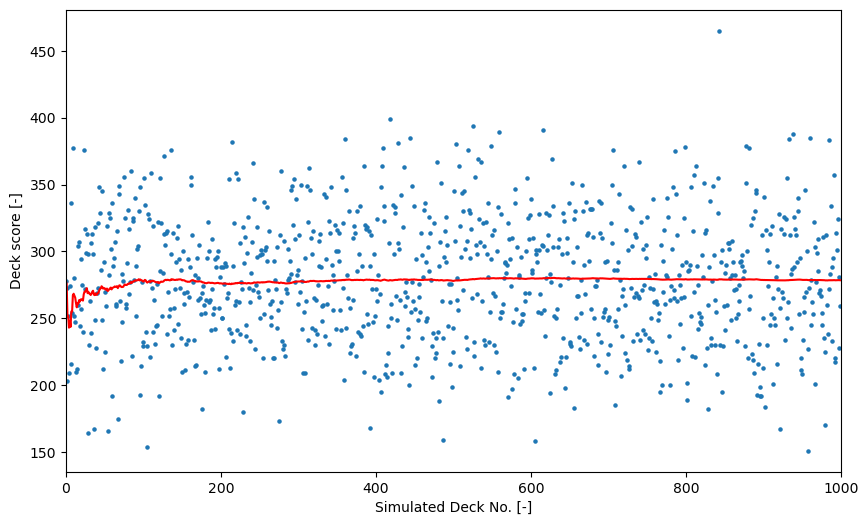

In [9]:
# Plot results
if run_analysis_2 == 1:
    X_2 = [x for x in range(0,it)]
    Y_2 = game_deck_scores
    Y_2_avg = np.cumsum(np.array(Y_2)) / np.arange(1, len(Y_2) + 1)
    fig = plt.figure(figsize=(10,6))
    plt.scatter(X_2,Y_2, s=5)
    plt.plot(X_2,Y_2_avg,'r-')
    plt.xlim(0,it) 
    #plt.ylim(0,250) 
    plt.xlabel('Simulated Deck No. [-]')
    plt.ylabel('Deck score [-]')
    plt.savefig("plots/Game Deck Scores plus Moving Average.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

Mean (mu) = 278.47
StDev (sigma) = 46.13


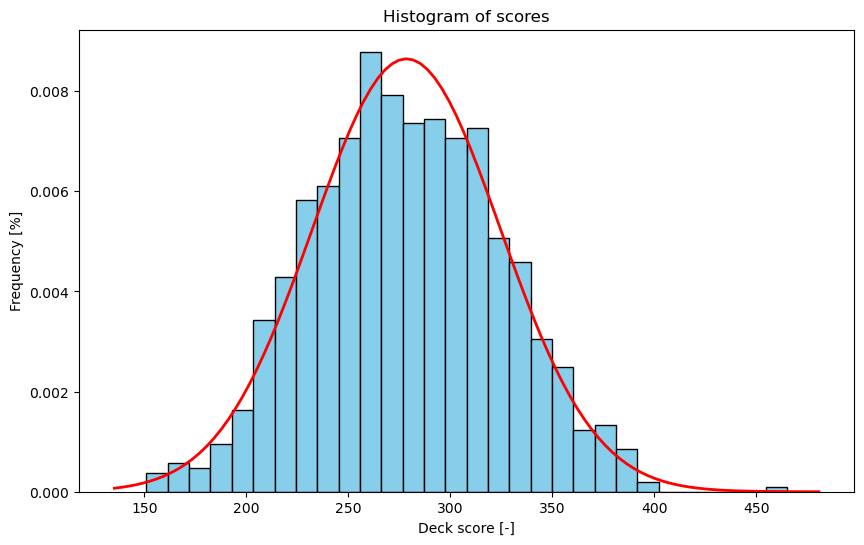

In [10]:
# Evaluate the statistic of the observed distribution

if run_analysis_2 == 1:
    # Check distribution shape
    fig = plt.figure(figsize=(10,6))
    plt.hist(Y_2, bins=30, color="skyblue", edgecolor="black", density=True)

    # Calculate statistics
    mu_2, std_2 = norm.fit(Y_2)
    print("Mean (mu) = {:.2f}\nStDev (sigma) = {:.2f}".format(mu_2, std_2))

    # Create x-value range for norm curve
    xmin, xmax = plt.xlim()
    x_2 = np.linspace(xmin, xmax, 100)
    p_2 = norm.pdf(x_2, mu_2, std_2)
    plt.plot(x_2, p_2, 'r', linewidth=2)

    #Show plot
    plt.title("Histogram of scores")
    plt.xlabel("Deck score [-]")
    plt.ylabel("Frequency [%]")
    plt.savefig("plots/Distribution of Game Deck Scores.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

In [11]:
# Save results to existing dataframe
if run_analysis_2 == 1:
    df = pd.read_csv("Study_Data.csv")
    df['Game Deck Scores'] = Y_2
    df.to_csv("Study_Data.csv", index=False)

## Demonstrate the distribution differences

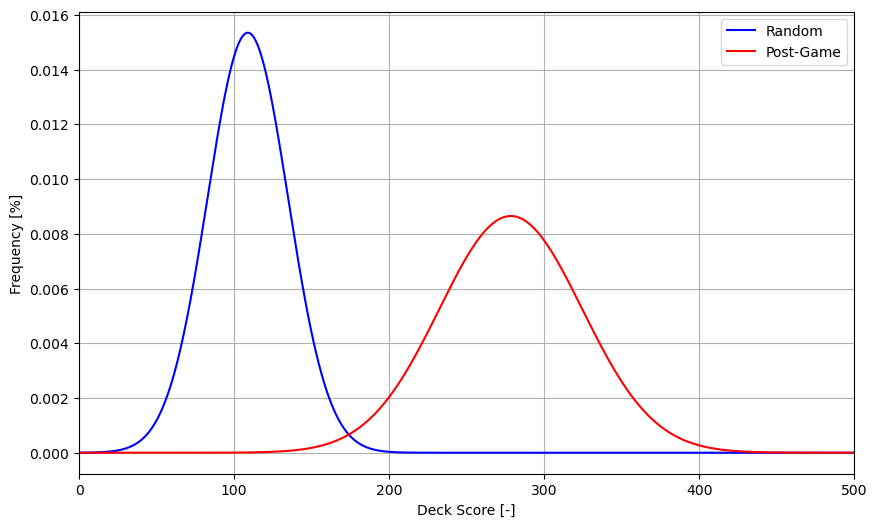

In [12]:
# Create dual normal distribution plots
plt.figure(figsize=(10,6)) 

# Define the x space
x = np.linspace(0,500,1000) 

# Define the y points
y1 = norm.pdf(x, mu_1, std_1)
y2 = norm.pdf(x, mu_2, std_2) 

# Plot both distributions
plt.plot(x, y1, label="Random", color="blue") 
plt.plot(x, y2, label="Post-Game", color="red")  

# Add labels and legend
plt.xlabel("Deck Score [-]") 
plt.ylabel("Frequency [%]") 
plt.xlim(min(x), max(x)) 
plt.legend() 
plt.grid(True) 

# Save the plot
plt.savefig("plots/Combined Distribution Plot.png", dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show() 

## Analyse the affect of riffle shuffling the packs

In [23]:
# Run third analysis
run_analysis_3 = 1

if run_analysis_3 == 1:

    # Decide number of players
    no_players = 4
    
    # Simulate 
    it = 1000
    no_shuffles = 5
    riffle_shuffled_deck_scores = [[] for x in range(0,no_shuffles)]
    
    for i in range(0,it):

        #Create test deck
        test_deck = create_game_deck(no_players, card_sets, card_runs)

        #Calcualate deck's score
        for j in range(0,no_shuffles):
            deck_score = find_deck_score(deck_size, hand_size, card_sets, card_runs, test_deck)
            riffle_shuffled_deck_scores[j].append(deck_score)
            test_deck = riffle_shuffle(test_deck)

    print("done")

done


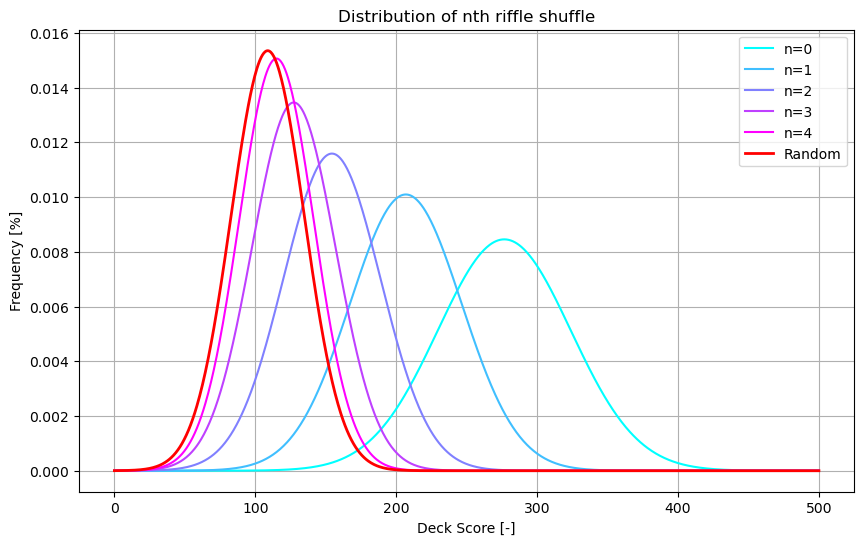

In [24]:
if run_analysis_3 == 1:

    # Create dataframe for results
    df_3 = pd.DataFrame()
    for i in range(0,len(riffle_shuffled_deck_scores)):
        col = "Shuffle_{}".format(i)
        df_3[col] = riffle_shuffled_deck_scores[i]
    df_3.head()

    # Plot the results
    plt.figure(figsize=(10,6)) 

    # Call in colour map
    #from matplotlib import cm
    cmap = plt.get_cmap('cool', no_shuffles)

    # Define the x-range
    x = np.linspace(0,500,1000)

    # Define the y values and plot them
    for i in range(0, no_shuffles):
        mu_i = df_3.iloc[:,i].mean()
        sigma_i = df_3.iloc[:,i].std() 
        y_i = norm.pdf(x, mu_i, sigma_i) 
        plt.plot(x, y_i, color=cmap(i), label="n={}".format(i))
    plt.plot(x, y1, 'r', linewidth=2, label='Random')

    # Pretty the graph
    plt.title("Distribution of nth riffle shuffle")
    plt.xlabel("Deck Score [-]") 
    plt.ylabel("Frequency [%]") 
    plt.legend() 
    plt.grid(True)

    # Save the plot
    plt.savefig("plots/Distribution of nth riffle shuffle.png", dpi=300, bbox_inches='tight', transparent=True)

    # Show plot
    plt.show()

## Analyse the affect of overhand shuffle the packs

In [32]:
# Run fourth analysis
run_analysis_4 = 1

if run_analysis_4 == 1:

    # Decide number of players
    no_players = 4
    
    # Simulate 
    it = 1000
    no_shuffles = 15
    overhand_shuffled_deck_scores = [[] for x in range(0,no_shuffles)]
    
    for i in range(0,it):

        #Create test deck
        test_deck = create_game_deck(no_players, card_sets, card_runs)

        #Calcualate deck's score
        for j in range(0,no_shuffles):
            deck_score = find_deck_score(deck_size, hand_size, card_sets, card_runs, test_deck) #score
            overhand_shuffled_deck_scores[j].append(deck_score) #add to library
            test_deck = over_shuffle(test_deck) #shuffle

    print("done")


done


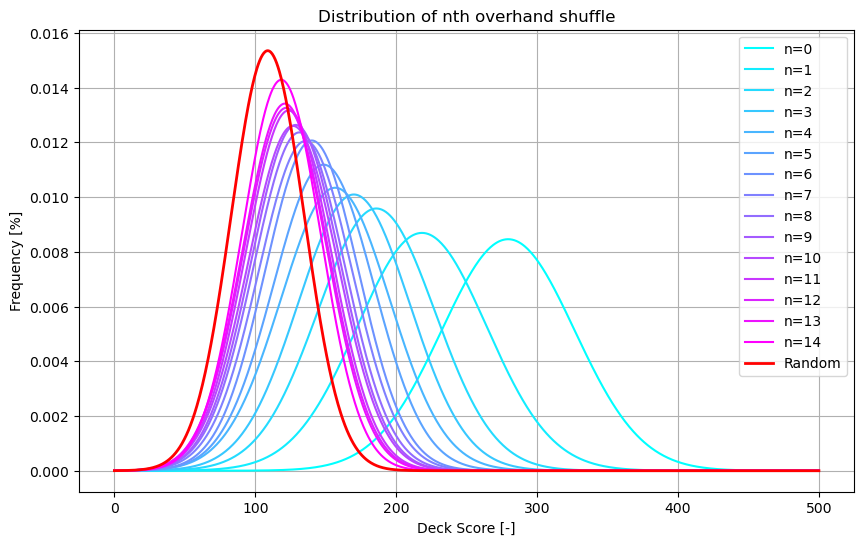

In [61]:
if run_analysis_4 == 1:

    # Create dataframe for results
    df_4 = pd.DataFrame()
    for i in range(0,len(overhand_shuffled_deck_scores)):
        col = "Shuffle_{}".format(i)
        df_4[col] = overhand_shuffled_deck_scores[i]
    df_4.head()

    # Plot the results
    plt.figure(figsize=(10,6)) 

    # Call in colour map
    cmap = plt.get_cmap('cool', no_shuffles)

    # Define the x-range
    x = np.linspace(0,500,1000)

    # Define the y values and plot them
    for i in range(0, no_shuffles):
        mu_i = df_4.iloc[:,i].mean()
        sigma_i = df_4.iloc[:,i].std() 
        y_i = norm.pdf(x, mu_i, sigma_i) 
        plt.plot(x, y_i, color=cmap(i), label="n={}".format(i))
    plt.plot(x, y1, 'r', linewidth=2, label='Random')

    # Pretty the graph
    plt.title("Distribution of nth overhand shuffle")
    plt.xlabel("Deck Score [-]") 
    plt.ylabel("Frequency [%]") 
    plt.legend() 
    plt.grid(True)

    # Save the plot
    plt.savefig("plots/Distribution of nth overhand shuffle.png", dpi=300, bbox_inches='tight', transparent=True)

    # Show plot
    plt.show()

## Analyse of affect of overhand and restack shuffling the packs

In [58]:
# Run fourth analysis
run_analysis_5 = 1

if run_analysis_5 == 1:

    # Decide number of players
    no_players = 4
    
    # Simulate 
    it = 1000
    no_shuffles = 15
    overhand_restack_shuffled_deck_scores = [[] for x in range(0,no_shuffles)]
    
    for i in range(0,it):

        #Create test deck
        test_deck = create_game_deck(no_players, card_sets, card_runs)

        #Calcualate deck's score
        for j in range(0,no_shuffles):
            deck_score = find_deck_score(deck_size, hand_size, card_sets, card_runs, test_deck) #score
            overhand_restack_shuffled_deck_scores[j].append(deck_score) #add to library
            test_deck = over_shuffle(test_deck) #shuffle
            test_deck = restrack_deck(test_deck) # restrack

    print("done")

done


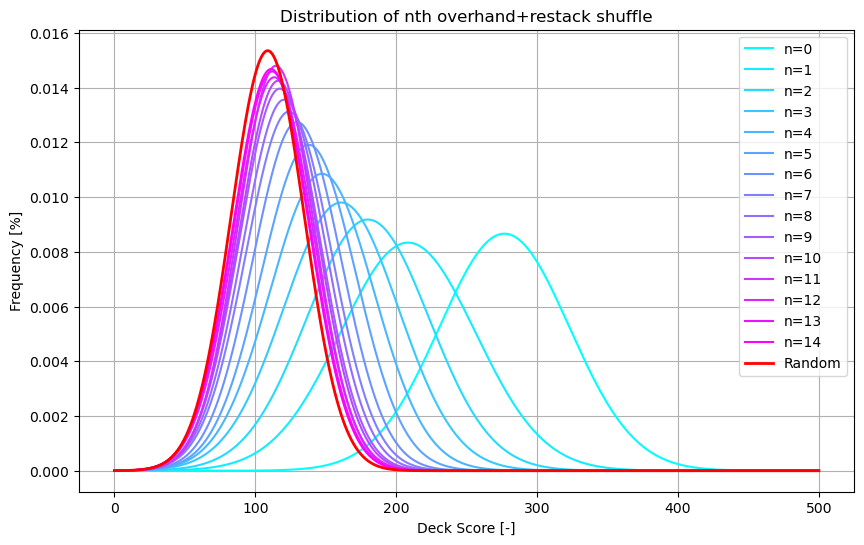

In [62]:
if run_analysis_5 == 1:

    # Create dataframe for results
    df_5 = pd.DataFrame()
    for i in range(0,len(overhand_restack_shuffled_deck_scores)):
        col = "Shuffle_{}".format(i)
        df_5[col] = overhand_restack_shuffled_deck_scores[i]
    df_5.head()

    # Plot the results
    plt.figure(figsize=(10,6)) 

    # Call in colour map
    cmap = plt.get_cmap('cool', no_shuffles)

    # Define the x-range
    x = np.linspace(0,500,1000)

    # Define the y values and plot them
    for i in range(0, no_shuffles):
        mu_i = df_5.iloc[:,i].mean()
        sigma_i = df_5.iloc[:,i].std() 
        y_i = norm.pdf(x, mu_i, sigma_i) 
        plt.plot(x, y_i, color=cmap(i), label="n={}".format(i))
    plt.plot(x, y1, 'r', linewidth=2, label='Random')

    # Pretty the graph
    plt.title("Distribution of nth overhand+restack shuffle")
    plt.xlabel("Deck Score [-]") 
    plt.ylabel("Frequency [%]") 
    plt.legend() 
    plt.grid(True)

    # Save the plot
    plt.savefig("plots/Distribution of nth overhand+restack shuffle.png", dpi=300, bbox_inches='tight', transparent=True)

    # Show plot
    plt.show()

## Check convergence for number of iterations selected

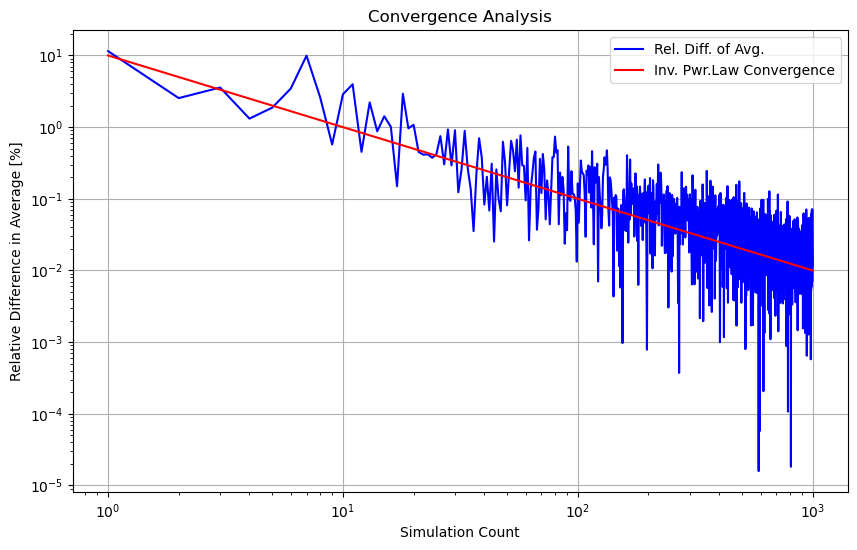

In [90]:
from scipy.optimize import curve_fit

# Analysis of convergence
num_sims = np.array(X_1)
sim_scores = np.array(Y_1)
avg_scores = np.array(Y_1_avg)
reldiff = abs((avg_scores[1:] - avg_scores[:-1]) / avg_scores[:-1] * 100)

# Define a power law
def power_law(x, k, n):
    return k * x**(-n)

# Fit the model
#params, covariance = curve_fit(power_law, num_sims[1:], reldiff, p0=[0, 0]) 
#k_fit, n_fit = params
#print(k_fit, n_fit)

# Generate the y-values
y_fit = power_law(num_sims[1:], float(10), float(1))

# Plot results
plt.figure(figsize=(10,6)) 
plt.plot(num_sims[1:], reldiff, 'b-', label='Rel. Diff. of Avg.')
plt.plot(num_sims[1:], y_fit, 'r-', label='Inv. Pwr.Law Convergence')

# Add details
plt.title("Convergence Analysis") 
plt.xlabel("Simulation Count") 
plt.ylabel("Relative Difference in Average [%]")
plt.grid(True)
plt.xscale('log') 
plt.yscale('log') 
plt.legend()

# Save plot
plt.savefig("plots/Convergence Analysis of Average vs. Simulation Count.png", dpi=300, bbox_inches='tight', transparent=True)

# Show plot
plt.show() 